# Project Overview

This notebook analyzes the Online Retail transactions, summarizes sales and customer behavior, and applies Recency, Frequency, and Monetary (RFM) scoring to segment identified customers. It uses the original Excel dataset and a reproducible transaction-cleaning methodology.

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [4]:
%pushd ../data/online+retail
file_path = "Online Retail.xlsx"
df = pd.read_excel(file_path)
%popd

print("Dataset shape:", df.shape)
display(df.head())

d:\SQL\Online-Retail-Customer-Analytics\data\online+retail
d:\SQL\Online-Retail-Customer-Analytics\python
popd -> d:\SQL\Online-Retail-Customer-Analytics\python
Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Initial Data Inspection

Review the raw dataset dimensions, schema, completeness, exact duplicates, and numeric distributions before cleaning.

In [5]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("Column names:", df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="Data Type"))

print("\nMissing values by column:")
display(df.isna().sum().to_frame(name="Missing Values"))

print("Exact duplicate rows:", df.duplicated().sum())
print("\nDescriptive statistics for numeric columns:")
display(df.describe())

Rows: 541,909
Columns: 8
Column names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:


,Data Type
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[us]
UnitPrice,float64
CustomerID,float64
Country,str



Missing values by column:


,Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Exact duplicate rows: 5268

Descriptive statistics for numeric columns:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# Data Quality Checks

These checks describe the raw transactions before cleaning. An invoice number beginning with `C` identifies a cancelled invoice; negative quantities commonly represent returns or reversals. Zero or negative prices and quantities are reported before the cleaning rules remove them.

In [6]:
cancelled_mask = df["InvoiceNo"].astype(str).str.startswith("C")

quality_counts = pd.Series({
    "Cancelled invoices (InvoiceNo starts with C)": cancelled_mask.sum(),
    "Negative quantities (returns or reversals)": (df["Quantity"] < 0).sum(),
    "Zero quantities (no units recorded)": (df["Quantity"] == 0).sum(),
    "Negative prices (accounting adjustments)": (df["UnitPrice"] < 0).sum(),
    "Zero prices (no charge recorded)": (df["UnitPrice"] == 0).sum(),
    "Exact duplicate rows": df.duplicated().sum(),
    "Missing CustomerID (customer not identified)": df["CustomerID"].isna().sum(),
    "Missing Description (product text unavailable)": df["Description"].isna().sum(),
})

display(quality_counts.to_frame(name="Rows"))
print("Sample cancelled invoices:")
display(df.loc[cancelled_mask].head())

,Rows
Cancelled invoices (InvoiceNo starts with C),9288
Negative quantities (returns or reversals),10624
Zero quantities (no units recorded),0
Negative prices (accounting adjustments),2
Zero prices (no charge recorded),2515
Exact duplicate rows,5268
Missing CustomerID (customer not identified),135080
Missing Description (product text unavailable),1454


Sample cancelled invoices:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


# Data Cleaning

Apply one methodology to a copy of the raw data: remove exact duplicates, cancelled invoices, non-positive quantities, and non-positive prices, then calculate line revenue. Missing customer IDs and descriptions are not global exclusion rules. Missing customer IDs are excluded only from customer-level and RFM calculations.

In [7]:
df_clean = df.copy()

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print("Exact duplicate rows removed:", rows_before - len(df_clean))

rows_before = len(df_clean)
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
print("Cancelled invoice rows removed:", rows_before - len(df_clean))

rows_before = len(df_clean)
df_clean = df_clean[df_clean["Quantity"] > 0]
print("Non-positive quantity rows removed:", rows_before - len(df_clean))

rows_before = len(df_clean)
df_clean = df_clean[df_clean["UnitPrice"] > 0]
print("Non-positive price rows removed:", rows_before - len(df_clean))

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
print("Cleaned dataset shape:", df_clean.shape)

Exact duplicate rows removed: 5268
Cancelled invoice rows removed: 9251
Non-positive quantity rows removed: 1336
Non-positive price rows removed: 1176
Cleaned dataset shape: (524878, 9)


# Cleaning Validation

Confirm that each specified cleaning rule was applied, revenue matches quantity multiplied by unit price, and customer IDs were not used as a global row-removal criterion.

In [8]:
print("Cleaned rows:", len(df_clean))
print("Exact duplicates remaining:", df_clean.duplicated().sum())
print("Cancelled invoices remaining:", df_clean["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Non-positive quantities remaining:", (df_clean["Quantity"] <= 0).sum())
print("Non-positive prices remaining:", (df_clean["UnitPrice"] <= 0).sum())
print("Revenue calculation valid:", df_clean["Revenue"].equals(df_clean["Quantity"] * df_clean["UnitPrice"]))
print("Rows with missing CustomerID retained:", df_clean["CustomerID"].isna().sum())
print("Rows with missing Description retained:", df_clean["Description"].isna().sum())

Cleaned rows: 524878
Exact duplicates remaining: 0
Cancelled invoices remaining: 0
Non-positive quantities remaining: 0
Non-positive prices remaining: 0
Revenue calculation valid: True
Rows with missing CustomerID retained: 132186
Rows with missing Description retained: 0


# Sales Analysis

In [9]:
sales_summary = pd.Series({
    "Total Revenue": df_clean["Revenue"].sum(),
    "Average Transaction-Line Revenue": df_clean["Revenue"].mean(),
    "Maximum Transaction-Line Revenue": df_clean["Revenue"].max(),
    "Unique Invoices": df_clean["InvoiceNo"].nunique(),
})
display(sales_summary.to_frame(name="Value"))

order_analysis = (
    df_clean.groupby("InvoiceNo")
    .agg(
        Order_Revenue=("Revenue", "sum"),
        Total_Units=("Quantity", "sum"),
        Unique_Products=("StockCode", "nunique"),
        CustomerID=("CustomerID", "first"),
        Country=("Country", "first"),
    )
    .reset_index()
)

print("Average Order Value:", round(order_analysis["Order_Revenue"].mean(), 2))
print("Median Order Value:", round(order_analysis["Order_Revenue"].median(), 2))
display(order_analysis.head())

,Value
Total Revenue,1.064211e+07
Average Transaction-Line Revenue,2.027540e+01
Maximum Transaction-Line Revenue,1.684696e+05
Unique Invoices,1.996000e+04


Average Order Value: 533.17
Median Order Value: 303.3


,InvoiceNo,Order_Revenue,Total_Units,Unique_Products,CustomerID,Country
0,536365,139.12,40,7,17850.0,United Kingdom
1,536366,22.20,12,2,17850.0,United Kingdom
2,536367,278.73,83,12,13047.0,United Kingdom
3,536368,70.05,15,4,13047.0,United Kingdom
4,536369,17.85,3,1,13047.0,United Kingdom


# Country Analysis

Country-level sales use the cleaned transaction dataset, including transactions whose customer ID is missing. Customer counts and revenue per identified customer are descriptive customer-level metrics.

In [10]:
country_analysis = (
    df_clean.groupby("Country")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Units=("Quantity", "sum"),
        Unique_Customers=("CustomerID", "nunique"),
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)

country_analysis["Revenue_Per_Customer"] = (
    country_analysis["Total_Revenue"]
    / country_analysis["Unique_Customers"].replace(0, np.nan)
).round(2)

display(country_analysis.head(15))

international = country_analysis[
    (country_analysis["Country"] != "United Kingdom")
    & (country_analysis["Unique_Customers"] >= 5)
].sort_values("Revenue_Per_Customer", ascending=False)

display(
    international[
        ["Country", "Total_Revenue", "Unique_Customers", "Revenue_Per_Customer"]
    ].head(10)
)

,Country,Total_Revenue,Total_Orders,Total_Units,Unique_Customers,Revenue_Per_Customer
0,United Kingdom,9001744.094,18019,4646906,3920,2296.36
1,Netherlands,285446.340,94,200361,9,31716.26
2,EIRE,283140.520,288,147007,3,94380.17
3,Germany,228678.400,457,119154,94,2432.75
4,France,209625.370,392,112060,87,2409.49
5,Australia,138453.810,57,83891,9,15383.76
6,Spain,61558.560,90,27933,30,2051.95
7,Switzerland,57067.600,54,30617,21,2717.50
8,Belgium,41196.340,98,23237,25,1647.85
9,Sweden,38367.830,36,36078,8,4795.98


,Country,Total_Revenue,Unique_Customers,Revenue_Per_Customer
1,Netherlands,285446.34,9,31716.26
5,Australia,138453.81,9,15383.76
9,Sweden,38367.83,8,4795.98
10,Japan,37416.37,8,4677.05
11,Norway,36165.44,10,3616.54
7,Switzerland,57067.60,21,2717.50
3,Germany,228678.40,94,2432.75
4,France,209625.37,87,2409.49
15,Channel Islands,20440.54,9,2271.17
16,Denmark,18955.34,9,2106.15


# Product Analysis

For product rankings, retain the notebook's existing analytical convention of excluding non-product stock codes and descriptions containing “discount.” This product-only subset does not replace or alter the cleaned dataset used for overall sales and country totals.

In [11]:
non_product_codes = ["AMAZONFEE", "POST", "DOT", "B"]
df_sales = df_clean[
    ~df_clean["StockCode"].isin(non_product_codes)
    & ~df_clean["Description"].astype(str).str.contains("discount", case=False, na=False)
].copy()

df_sales["YearMonth"] = df_sales["InvoiceDate"].dt.to_period("M")
monthly_revenue = (
    df_sales.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

top_products = (
    df_sales.groupby("Description")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Units_Sold=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique"),
    )
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
    .reset_index()
)

display(top_products)

,Description,Total_Revenue,Units_Sold,Transactions
0,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
1,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2,WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2256
3,PARTY BUNTING,99445.23,18283,1685
4,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
5,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
6,Manual,77752.82,6985,290
7,RABBIT NIGHT LIGHT,66870.03,30739,994
8,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
9,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455


# Customer Analysis

In [12]:
customer_data = df_clean.dropna(subset=["CustomerID"]).copy()

customer_analysis = (
    customer_data.groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Units=("Quantity", "sum"),
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)

print("Identified customers:", customer_analysis["CustomerID"].nunique())
display(customer_analysis.head(10))

Identified customers: 4338


,CustomerID,Total_Revenue,Total_Orders,Total_Units
0,14646.0,280206.02,73,196915
1,18102.0,259657.30,60,64124
2,17450.0,194390.79,46,69973
3,16446.0,168472.50,2,80997
4,14911.0,143711.17,201,80240
5,12415.0,124914.53,21,77374
6,14156.0,117210.08,55,57768
7,17511.0,91062.38,31,64549
8,16029.0,80850.84,63,40108
9,12346.0,77183.60,1,74215


# RFM Analysis

RFM is calculated only for identified customers. Recency is measured in days from each customer's most recent invoice to the day after the dataset's last invoice; Frequency counts distinct invoices; Monetary sums cleaned transaction revenue.

In [13]:
analysis_date = customer_data["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    customer_data.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda dates: (analysis_date - dates.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)

print("RFM customer count:", len(rfm))
print("Analysis date:", analysis_date)
display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

RFM customer count: 4338
Analysis date: 2011-12-10 12:50:00


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


# RFM Scoring

Assign quintile scores from 1 to 5. Recency is reverse-scored so fewer days since the last purchase receives a higher score. Frequency and Monetary are scored in ascending order so higher values receive higher scores. Tied Frequency and Monetary values are ranked first to form five comparable groups.

In [14]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop",
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)
rfm["RFM_Total"] = rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

display(rfm.head(10))
print("RFM total score distribution:")
display(rfm["RFM_Total"].value_counts().sort_index().to_frame(name="Customers"))

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346.0,326,1,77183.60,1,1,5,115,7
1,12347.0,2,7,4310.00,5,5,5,555,15
2,12348.0,75,4,1797.24,2,4,4,244,10
3,12349.0,19,1,1757.55,4,1,4,414,9
4,12350.0,310,1,334.40,1,1,2,112,4
5,12352.0,36,8,2506.04,3,5,5,355,13
6,12353.0,204,1,89.00,1,1,1,111,3
7,12354.0,232,1,1079.40,1,1,4,114,6
8,12355.0,214,1,459.40,1,1,2,112,4
9,12356.0,23,3,2811.43,4,3,5,435,12


RFM total score distribution:


,Customers
RFM_Total,
3,183
4,361
5,337
6,426
7,377
8,375
9,336
10,342
11,347


# Customer Segmentation

In [15]:
def segment_customer(row):
    recency_score = row["R_Score"]
    frequency_score = row["F_Score"]

    if recency_score >= 4 and frequency_score >= 4:
        return "Champions"
    if recency_score >= 3 and frequency_score >= 3:
        return "Loyal Customers"
    if recency_score >= 4 and frequency_score <= 2:
        return "New Customers"
    if recency_score == 3 and frequency_score <= 2:
        return "Potential Loyalists"
    if recency_score <= 2 and frequency_score >= 4:
        return "Cannot Lose Them"
    if recency_score <= 2 and frequency_score == 3:
        return "At Risk"
    if recency_score <= 2 and frequency_score <= 2:
        return "Lost Customers"
    return "Needs Attention"


rfm["Customer_Segment"] = rfm.apply(segment_customer, axis=1)
display(rfm["Customer_Segment"].value_counts().to_frame(name="Customers"))

,Customers
Customer_Segment,
Champions,1139
Lost Customers,1065
Loyal Customers,821
At Risk,368
Potential Loyalists,351
New Customers,319
Cannot Lose Them,275


# RFM Segment Summary

In [16]:
segment_analysis = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Total_Revenue=("Monetary", "sum"),
        Avg_Monetary=("Monetary", "mean"),
    )
    .sort_values("Total_Revenue", ascending=False)
)
segment_analysis["Revenue_%"] = (
    segment_analysis["Total_Revenue"] / segment_analysis["Total_Revenue"].sum() * 100
)
display(segment_analysis.round(2))

,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Monetary,Revenue_%
Customer_Segment,,,,,,
Champions,1139,13.31,9.99,5913422.08,5191.77,66.54
Loyal Customers,821,38.04,3.64,1351084.30,1645.66,15.20
Lost Customers,1065,217.90,1.10,518322.15,486.69,5.83
Cannot Lose Them,275,137.08,4.89,431639.27,1569.60,4.86
At Risk,368,164.63,2.29,366413.24,995.69,4.12
Potential Loyalists,351,53.50,1.16,161108.11,459.00,1.81
New Customers,319,18.52,1.24,145219.74,455.23,1.63


# Visualizations

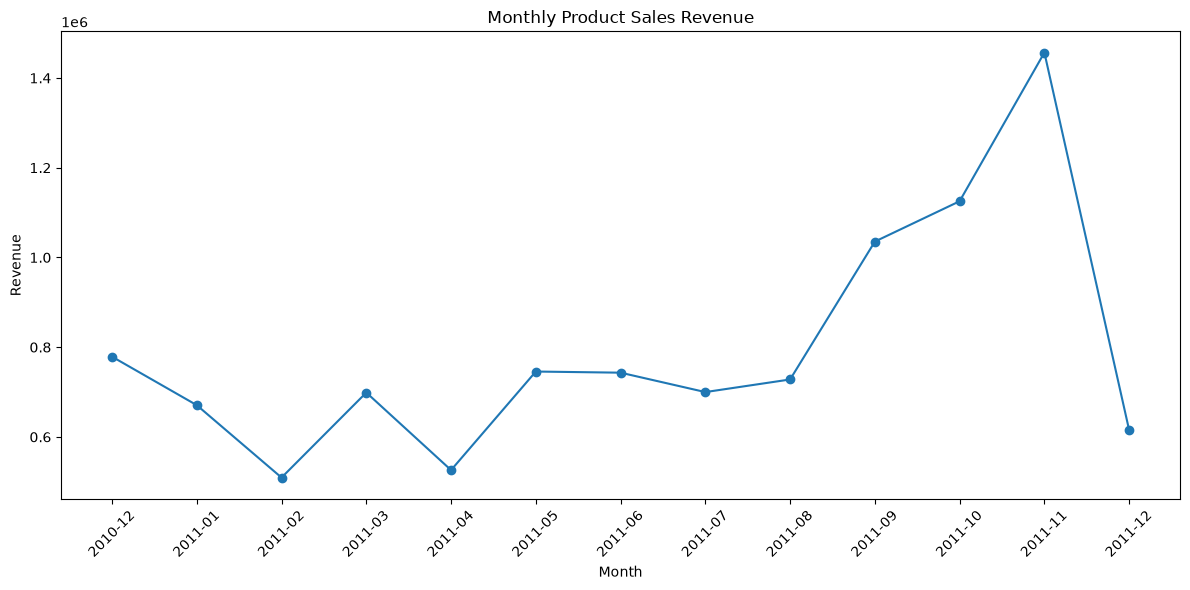

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue["YearMonth"].astype(str), monthly_revenue["Revenue"], marker="o")
plt.title("Monthly Product Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

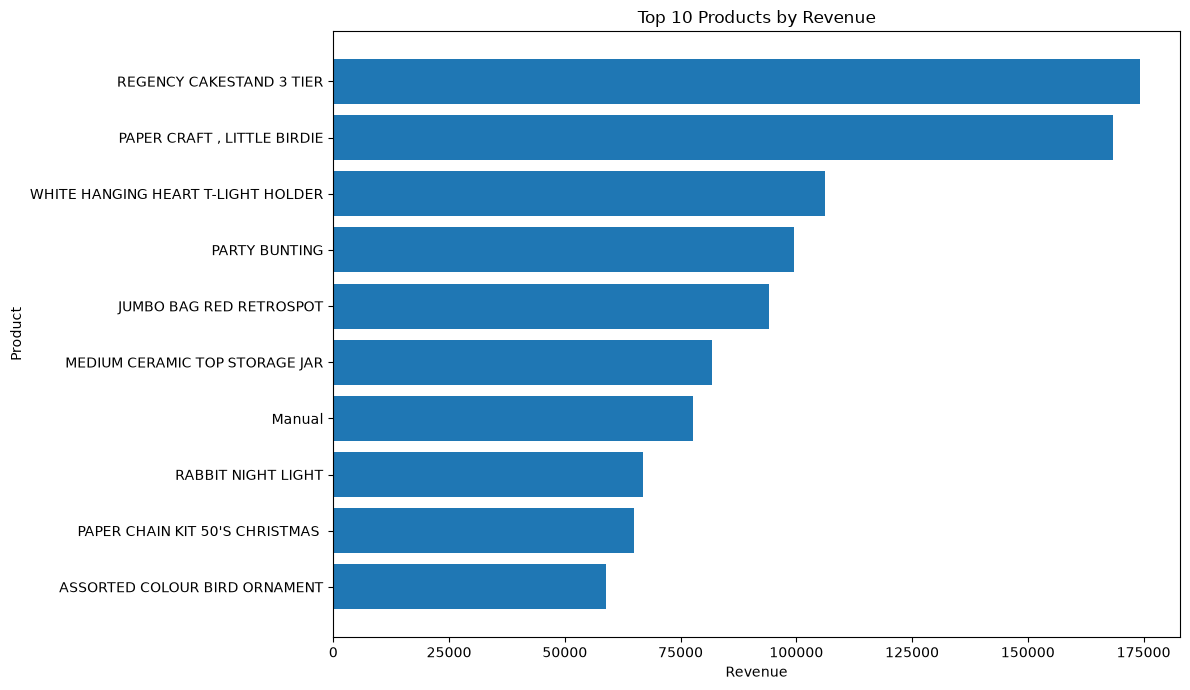

In [18]:
plt.figure(figsize=(12, 7))
plt.barh(top_products["Description"][::-1], top_products["Total_Revenue"][::-1])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

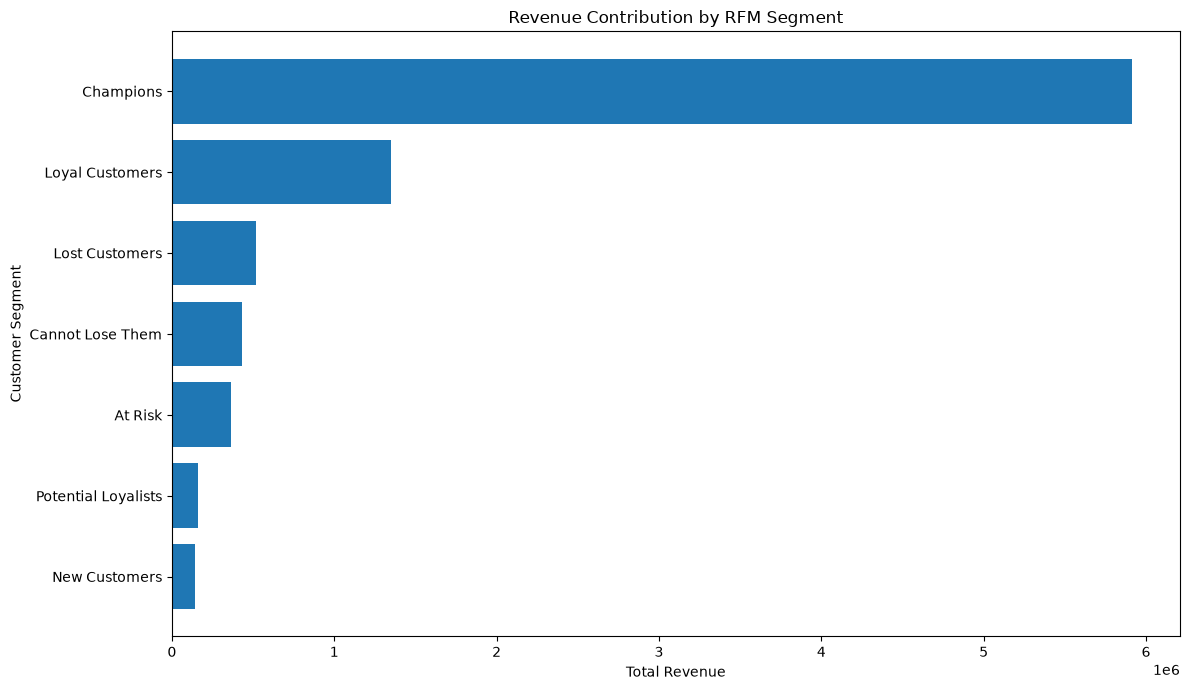

In [19]:
segment_plot = segment_analysis.sort_values("Total_Revenue", ascending=True)
plt.figure(figsize=(12, 7))
plt.barh(segment_plot.index, segment_plot["Total_Revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Customer Segment")
plt.title("Revenue Contribution by RFM Segment")
plt.tight_layout()
plt.show()

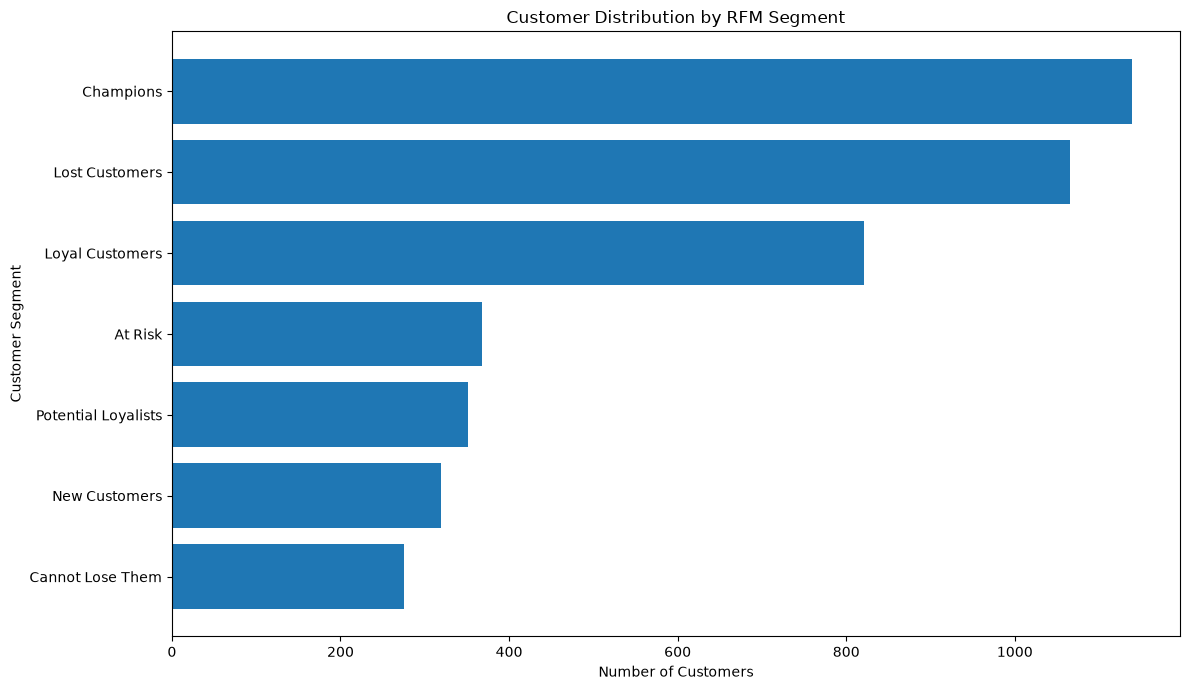

In [20]:
segment_count = rfm["Customer_Segment"].value_counts().sort_values(ascending=True)
plt.figure(figsize=(12, 7))
plt.barh(segment_count.index, segment_count.values)
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.title("Customer Distribution by RFM Segment")
plt.tight_layout()
plt.show()

# Export Results

Export the cleaned transaction-level dataset with RFM attributes attached where a customer ID is available, plus the customer-level RFM table. Transactions without a customer ID remain in the transaction export.

In [21]:
final_data = df_clean.merge(
    rfm[
        [
            "CustomerID",
            "Recency",
            "Frequency",
            "Monetary",
            "R_Score",
            "F_Score",
            "M_Score",
            "RFM_Score",
            "RFM_Total",
            "Customer_Segment",
        ]
    ],
    on="CustomerID",
    how="left",
)

final_data.to_csv("online_retail_final.csv", index=False)
rfm.to_csv("RFM_Customer_Segmentation.csv", index=False)
print("Exported online_retail_final.csv and RFM_Customer_Segmentation.csv")

Exported online_retail_final.csv and RFM_Customer_Segmentation.csv


# Final Summary

This analysis starts from the original transaction file, applies the stated sales-cleaning rules, and keeps unidentified-customer transactions in sales, country, and transaction-level exports. Customer-level metrics and RFM segmentation use only records with a CustomerID. The values below are computed from the loaded dataset when the notebook is run from top to bottom.

In [22]:
print("Cleaned sales rows:", f"{len(df_clean):,}")
print("Cleaned sales revenue:", f"{df_clean['Revenue'].sum():,.2f}")
print("Identified customers:", f"{rfm['CustomerID'].nunique():,}")
print("RFM segments:", rfm["Customer_Segment"].nunique())
print("Top country by revenue:", country_analysis.iloc[0]["Country"])
print("Top product by revenue:", top_products.iloc[0]["Description"])

Cleaned sales rows: 524,878
Cleaned sales revenue: 10,642,110.80
Identified customers: 4,338
RFM segments: 7
Top country by revenue: United Kingdom
Top product by revenue: REGENCY CAKESTAND 3 TIER
